1. Import Libraries

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats


In [6]:
prices = pd.read_csv("../data/jse_prices.csv", index_col=0, parse_dates=True)
prices.head()

,Naspers,MTN Group,Standard Bank,Anglo American,Shoprite
Date,,,,,
2019-01-02,29983.453125,8676.860352,35012.960938,17483.171875,18221.873047
2019-01-03,30043.001953,8616.020508,35063.253906,17768.867188,18462.382812
2019-01-04,30233.337891,8705.782227,35874.148438,17990.855469,18761.771484
2019-01-07,30414.896484,8725.730469,35475.617188,17819.634766,18816.656250
2019-01-08,30586.689453,8626.993164,35647.601562,17917.187500,18644.011719


In [ ]:
#  instead of working with raw prices, 
# We use log returns instead of simple returns because they handle compounding better and are more statistically stable.
returns = np.log(prices / prices.shift(1)).dropna()
returns.head()

,Naspers,MTN Group,Standard Bank,Anglo American,Shoprite
Date,,,,,
2019-01-03,0.001984,-0.007036,0.001435,0.016209,0.013113
2019-01-04,0.006315,0.010364,0.022863,0.012416,0.016086
2019-01-07,0.005987,0.002289,-0.011171,-0.009563,0.002921
2019-01-08,0.005632,-0.011380,0.004836,0.005460,-0.009217
2019-01-09,0.025210,0.008633,0.047360,0.004490,0.014085


In [54]:
print("Summary Stats:\n")
print(returns.describe().round(4))

Summary Stats:

         Naspers  MTN Group  Standard Bank  Anglo American   Shoprite
count  1497.0000  1497.0000      1497.0000       1497.0000  1497.0000
mean      0.0389     0.0045         0.0577          0.0157     0.0326
std       2.4958     2.7595         2.6112          2.0642     1.9585
min     -14.2940   -19.7304       -19.4758        -13.6465   -15.3301
25%      -1.2838    -1.2289        -1.2637         -0.9823    -0.9790
50%       0.1030    -0.0175         0.0219          0.0512     0.0000
75%       1.4240     1.1800         1.3183          1.0424     0.9802
max      17.3282    17.5525        20.5305         11.7015    12.7779


In [55]:
COLORS = ["blue", "green", "red", "purple", "orange"]

Plot 1 — Price history

<Figure size 640x480 with 0 Axes>

✅ Saved 01_price_history.png


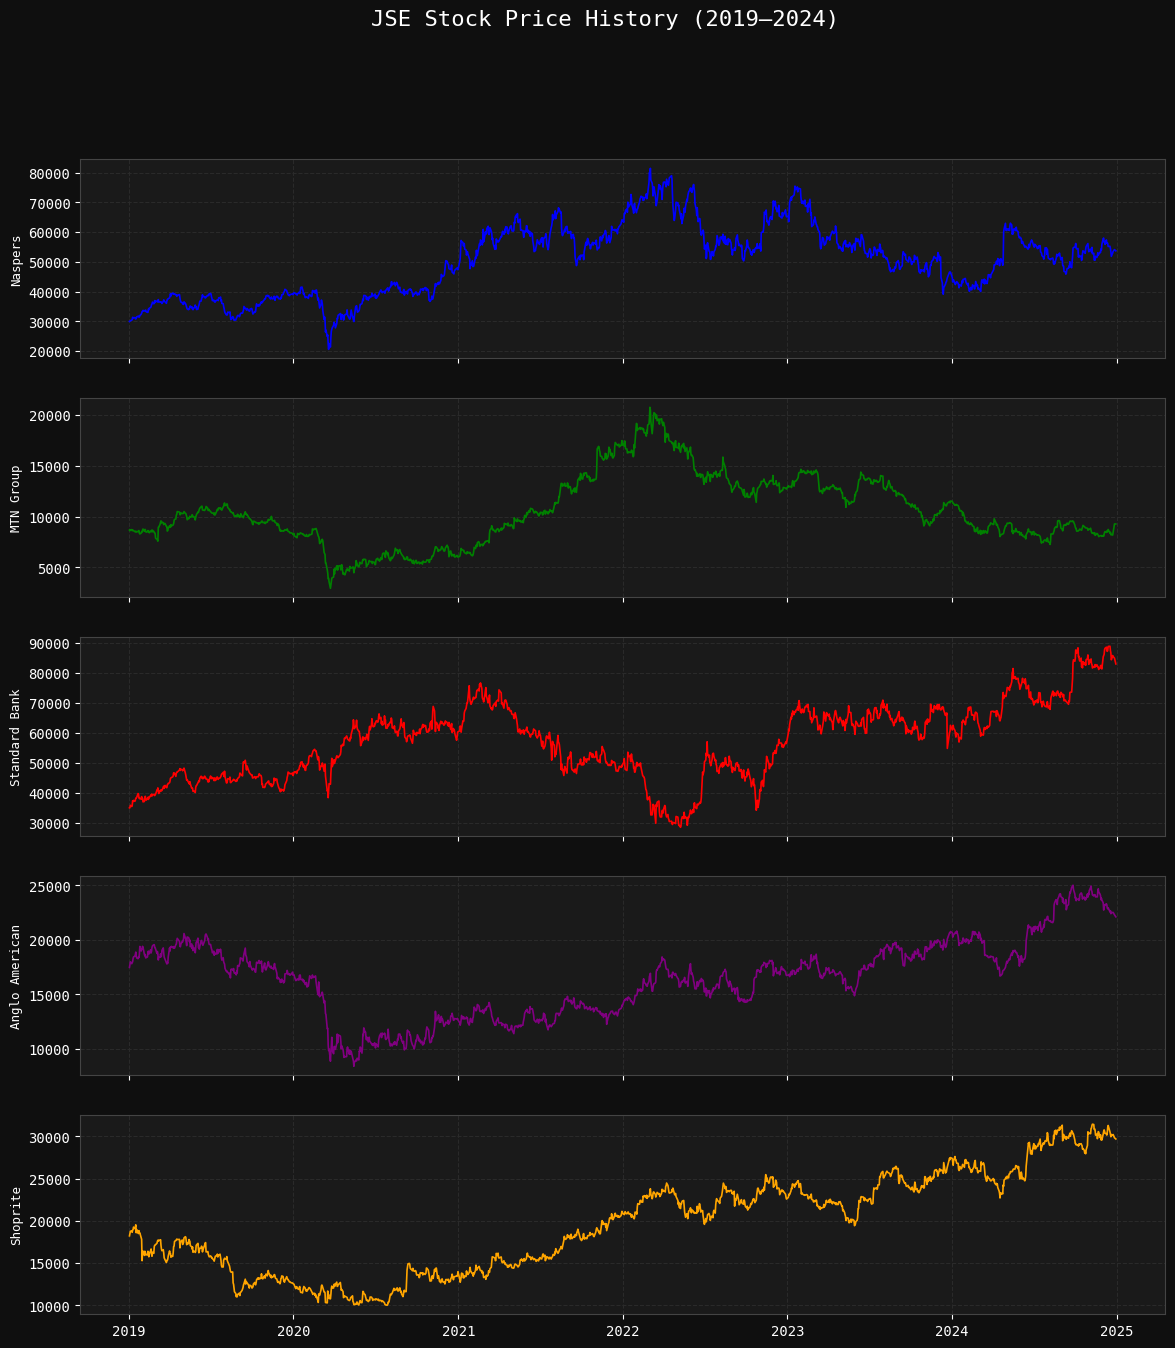

In [50]:
def plot_all_prices(prices, colors=None):
  
    n = len(prices.columns)
    
    fig, axes = plt.subplots(n, 1, figsize=(14, 3*n), sharex=True)
    fig.suptitle("JSE Stock Price History (2019–2024)", fontsize=16)
    
    if n == 1:
        axes = [axes]
    
    for i, col in enumerate(prices.columns):
        ax = axes[i]
        color = colors[i] if colors else None
        
        ax.plot(prices.index, prices[col], color=color, linewidth=1.2)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True)
    
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    
plt.tight_layout()
plt.savefig("../outputs/01_price_history.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved 01_price_history.png")
plot_all_prices(prices, COLORS)

Plot 2 — Daily Returns

✅ Saved 02_returns_history.png


<Figure size 640x480 with 0 Axes>

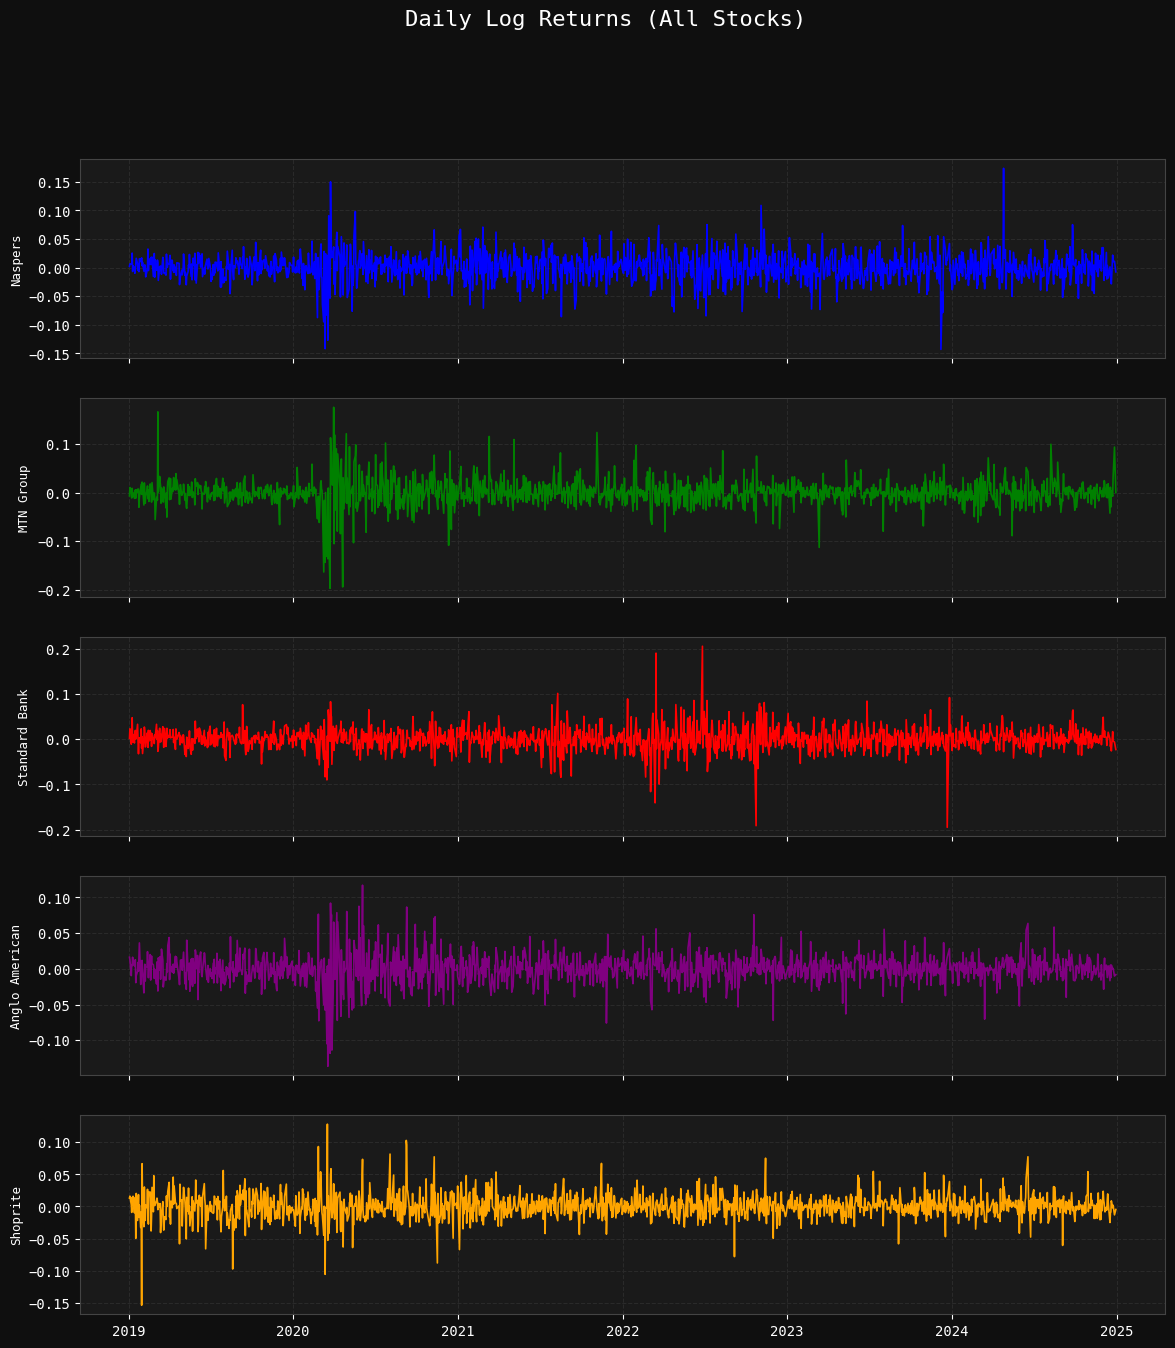

In [68]:
def plot_all_returns(returns, colors=None):

    
    n = len(returns.columns)
    
    fig, axes = plt.subplots(n, 1, figsize=(14, 3*n), sharex=True)
    fig.suptitle("Daily Log Returns (All Stocks)", fontsize=16)
    
    # Fix if only one stock
    if n == 1:
        axes = [axes]
    
    for i, col in enumerate(returns.columns):
        ax = axes[i]
        
        color = colors[i] if colors else None
        
        ax.plot(returns.index, returns[col], color=color, linewidth=1.2)
        ax.set_ylabel(col, fontsize=9)
        ax.grid(True)
    
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    
    plt.tight_layout()
    plt.savefig("../outputs/02_returns_history.png", dpi=150, bbox_inches="tight")
    print("✅ Saved 02_returns_history.png")
    plt.show()


plot_all_returns(returns, COLORS)

✅ Saved 03_return_distributions.png


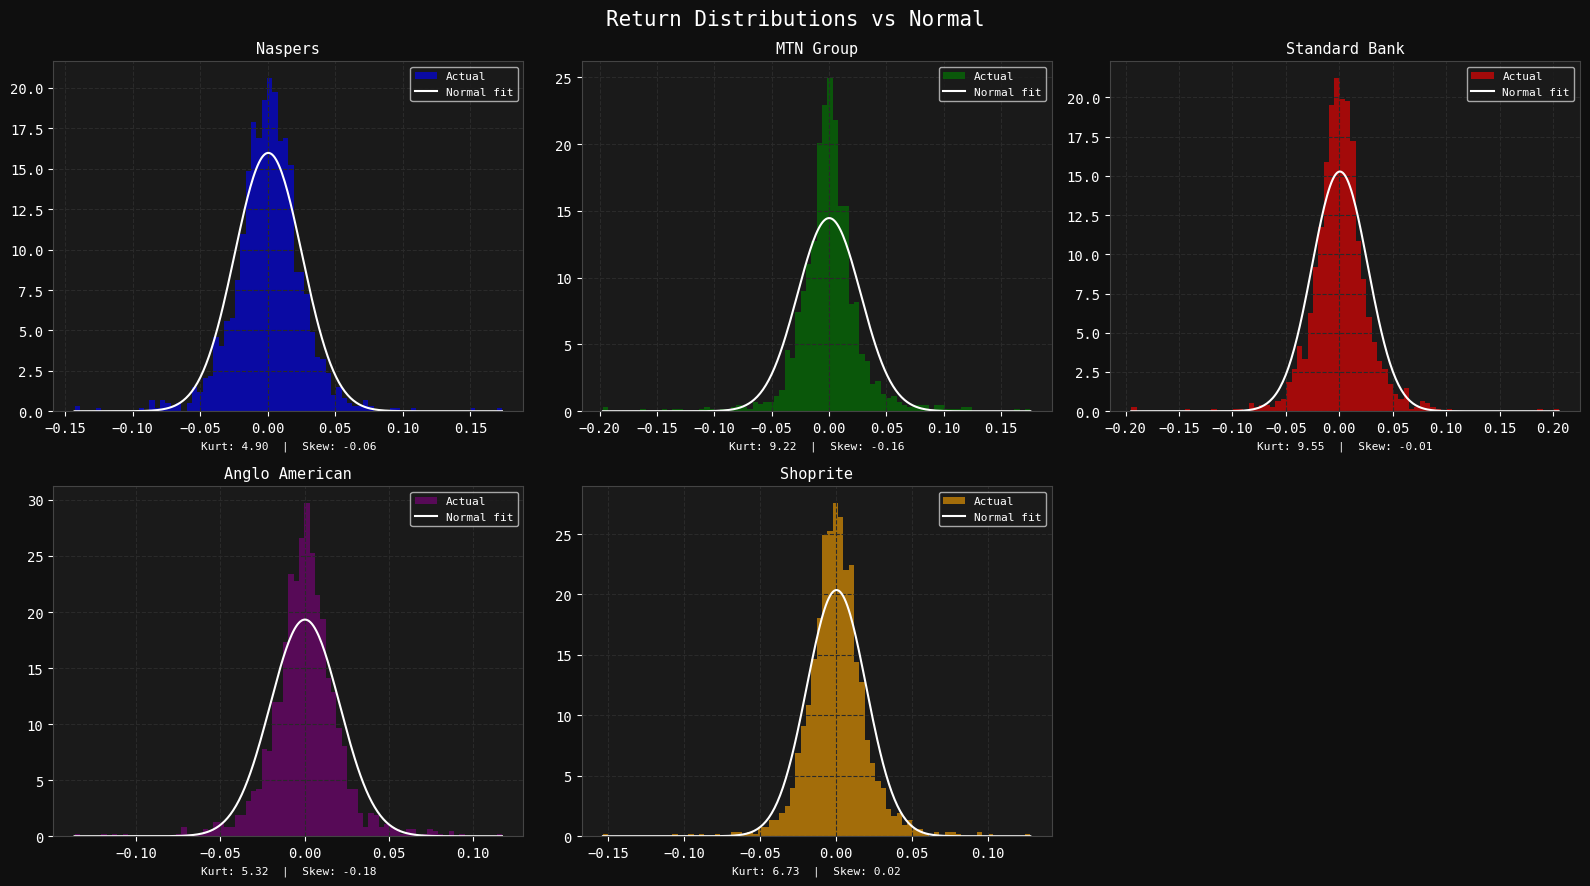

In [ ]:
# figure setup for return distribution plots and normal fit
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("Return Distributions vs Normal", fontsize=15)
axes = axes.flatten()

for i, (col, color) in enumerate(zip(returns.columns, COLORS)):
    ax = axes[i]
    data = returns[col].dropna()

    # histogram
    ax.hist(data, bins=80, color=color, alpha=0.6,
            density=True, label="Actual")

    # fitted normal curve
    mu, sigma = data.mean(), data.std()
    x = np.linspace(data.min(), data.max(), 300)
    ax.plot(x, stats.norm.pdf(x, mu, sigma),
            color="white", linewidth=1.5, label="Normal fit")

    # annotation
    kurt = data.kurt()
    skew = data.skew()
    ax.set_title(col, fontsize=11)
    ax.set_xlabel(f"Kurt: {kurt:.2f}  |  Skew: {skew:.2f}", fontsize=8)
    ax.legend(fontsize=8)
    ax.grid(True)

axes[-1].set_visible(False)   # hide 6th empty subplot

plt.tight_layout()
plt.savefig("../outputs/03_return_distributions.png", dpi=150, bbox_inches="tight")
print("✅ Saved 03_return_distributions.png")

plt.show()


✅ Saved 04_correlation_matrix.png


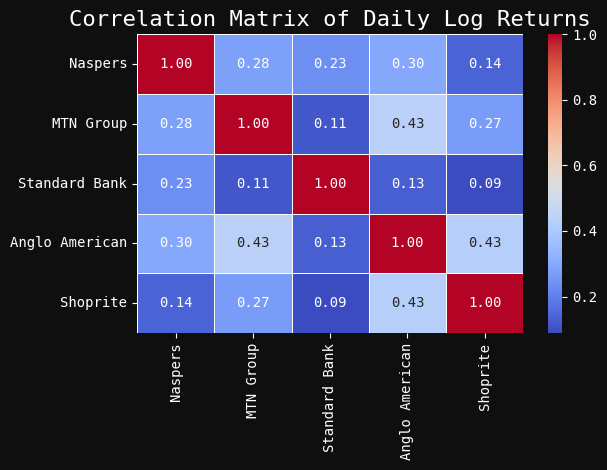

In [ ]:

corr = returns.corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Daily Log Returns", fontsize=16)
plt.savefig("../outputs/04_correlation_matrix.png", dpi=150, bbox_inches="tight")
print("✅ Saved 04_correlation_matrix.png")
plt.tight_layout()

In [ ]:
"""mean means average return, std measures volatility, skewness shows asymmetry(either left or right),
 kurtosis indicates tail risk, min and max show range of returns
"""
summary = pd.DataFrame({
    "Mean Return":   returns.mean(),
    "Std":       returns.std(),
    "Skewness":      returns.skew(),
    "Kurtosis":      returns.kurt(),
    "Min":           returns.min(),
    "Max":           returns.max(),
}).round(4)

summary

,Mean Return,Std,Skewness,Kurtosis,Min,Max
Naspers,0.0004,0.0250,-0.0601,4.8977,-0.1429,0.1733
MTN Group,0.0000,0.0276,-0.1620,9.2208,-0.1973,0.1755
Standard Bank,0.0006,0.0261,-0.0091,9.5477,-0.1948,0.2053
Anglo American,0.0002,0.0206,-0.1766,5.3204,-0.1365,0.1170
Shoprite,0.0003,0.0196,0.0191,6.7330,-0.1533,0.1278
